In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install biopython -q
# Test import
from Bio import SeqIO
print("Biopython ready!")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.7 MB/s eta 0:00:00
Biopython ready!


In [ ]:
from Bio import SeqIO
import gzip
fasta_path = '/content/drive/MyDrive/mtb_proteins.fasta'

with gzip.open(fasta_path, 'rt') as fasta_handle:
    sequences = list(SeqIO.parse(fasta_handle, 'fasta'))

print(f"Total proteins loaded: {len(sequences)}")
print(f"\nFirst protein ID: {sequences[0].id}")
print(f"First protein description: {sequences[0].description}")
print(f"Sequence length: {len(sequences[0].seq)} amino acids")

Total proteins loaded: 3997

First protein ID: sp|A0A089QRB9|MSL3_MYCTU
First protein description: sp|A0A089QRB9|MSL3_MYCTU Mycolipanoate synthase OS=Mycobacterium tuberculosis (strain ATCC 25618 / H37Rv) OX=83332 GN=msl3 PE=1 SV=2
Sequence length: 2085 amino acids


In [ ]:
#testing
lengths=[len(seq.seq) for seq in sequences]
print(f"Shortest protein : {min(lengths)} amino acids")
print(f"Longest protein : {max(lengths)} amino acids")
print(f"Average length : {sum(lengths)/len(lengths)} amino acids")

Shortest protein : 27 amino acids
Longest protein : 4151 amino acids
Average length : 333.2777082812109 amino acids


In [ ]:
#processing of protein records
from Bio import SeqIO
import gzip
data = []
fasta_path = '/content/drive/MyDrive/mtb_proteins.fasta'
with gzip.open(fasta_path, 'rt') as fasta_handle:
    for record in SeqIO.parse(fasta_handle, "fasta"):
        protein_id = record.id
        protein_sequence = str(record.seq)
        protein_description=record.description
        length = len(record.seq)
        data.append({"Protein_ID" : protein_id,
                     "Protein Sequence" : protein_sequence,
                     "Protein Description" : protein_description, # Added protein description here
                     "Length" : length})
print(f"Successfully processed {len(data)} protein records.")

Successfully processed 3997 protein records.


In [ ]:
#creation of dataframe
import pandas as pd
df=pd.DataFrame(data)
print(df.head())
print("\nDataframe shape:", df.shape)

                 Protein_ID  \
0  sp|A0A089QRB9|MSL3_MYCTU   
1      sp|I6WXK4|PTPB_MYCTU   
2     sp|I6WZG6|ENCAP_MYCTU   
3      sp|I6X235|ADPP_MYCTU   
4     sp|I6X8D2|PKS13_MYCTU   

                                    Protein Sequence  \
0  MRTATATSVAVIGMACRLPGGIDSPQRLWEALLRGDDLVGEIPADR...   
1  MAVRELPGAWNFRDVADTATALRPGRLFRSSELSRLDDAGRATLRR...   
2  MNNLYRDLAPVTEAAWAEIELEAARTFKRHIAGRRVVDVSDPGGPV...   
3  MAEHDFETISSETLHTGAIFALRRDQVRMPGGGIVTREVVEHFGAV...   
4  MADVAESQENAPAERAELTVPEMRQWLRNWVGKAVGKAPDSIDESV...   

                                 Protein Description  Length  
0  sp|A0A089QRB9|MSL3_MYCTU Mycolipanoate synthas...    2085  
1  sp|I6WXK4|PTPB_MYCTU Triple specificity protei...     276  
2  sp|I6WZG6|ENCAP_MYCTU Type 1 encapsulin shell ...     265  
3  sp|I6X235|ADPP_MYCTU ADP-ribose pyrophosphatas...     207  
4  sp|I6X8D2|PKS13_MYCTU Polyketide synthase Pks1...    1733  

Dataframe shape: (3997, 4)


In [ ]:
#writing into CSV file
df.to_csv('/content/drive/MyDrive/mtb_drug_targets/results/proteome_df.csv', index = False)
print("Saved!")

Saved!


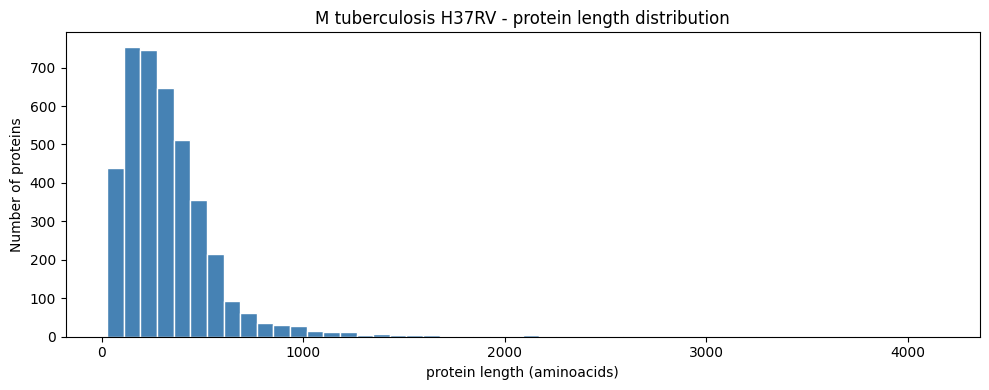

In [ ]:
#data visualization
import matplotlib.pyplot as plt
lengths=[len(seq.seq)for seq in sequences]
plt.figure(figsize=(10,4))
plt.hist(lengths, bins=50, color="steelblue",edgecolor='white')
plt.xlabel('protein length (aminoacids)')
plt.ylabel('Number of proteins')
plt.title("M tuberculosis H37RV - protein length distribution")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/mtb_drug_targets/results/length_distribution.png', dpi=150)
plt.show()

In [ ]:
#cleaning of dataframe
print("Duplicate IDs:", df['Protein_ID'].duplicated().sum())
print("Empty sequences:", df['Protein Sequence'].isna().sum())
print("Very short proteins (under 50 aa):", len(df[df['Length']<50]))
df_clean=df[df['Length']>=50].copy()
print(f"\nAfter cleaning : {len(df_clean)} proteins remain")
df_clean.to_csv('/content/drive/MyDrive/mtb_drug_targets/results/proteome_clean.csv',index=False)
print("clean data saved!")

Duplicate IDs: 0
Empty sequences: 0
Very short proteins (under 50 aa): 17

After cleaning : 3980 proteins remain
clean data saved!


In [ ]:
#extraction of protein names and description
def extract_protein_names(description):
  parts=description.split("|")
  if len(parts)>=3:
    name_part=parts[2]
    return name_part.split("OS=")[0].strip()
  return description
df_clean['protein_name']=df_clean['Protein Description'].apply(extract_protein_names)
print(df_clean[['Protein_ID','protein_name','Length']].head(10))

                 Protein_ID  \
0  sp|A0A089QRB9|MSL3_MYCTU   
1      sp|I6WXK4|PTPB_MYCTU   
2     sp|I6WZG6|ENCAP_MYCTU   
3      sp|I6X235|ADPP_MYCTU   
4     sp|I6X8D2|PKS13_MYCTU   
5      sp|I6XD65|PNCA_MYCTU   
6     sp|I6XD69|PKS12_MYCTU   
7     sp|I6XFS7|RDMTR_MYCTU   
8     sp|I6XHI4|FADA5_MYCTU   
9     sp|I6XU97|EST45_MYCTU   

                                        protein_name  Length  
0                  MSL3_MYCTU Mycolipanoate synthase    2085  
1  PTPB_MYCTU Triple specificity protein phosphat...     276  
2        ENCAP_MYCTU Type 1 encapsulin shell protein     265  
3              ADPP_MYCTU ADP-ribose pyrophosphatase     207  
4              PKS13_MYCTU Polyketide synthase Pks13    1733  
5           PNCA_MYCTU Nicotinamidase/pyrazinamidase     186  
6                PKS12_MYCTU Mycoketide-CoA synthase    4151  
7      RDMTR_MYCTU RNA/DNA methyltransferase Rv2966c     188  
8        FADA5_MYCTU Steroid 3-ketoacyl-CoA thiolase     391  
9                       EST4

In [ ]:
#final table
final_cols=['Protein_ID','protein_name','Length','Protein Sequence']
df_final=df_clean[final_cols].copy()
print(df_final.head())
print(f'\nFinal table: {df_final.shape[0]} proteins, {df_final.shape[1]} columns')
df_final.to_csv("/content/drive/MyDrive/mtb_drug_targets/results/proteome_final.csv", index=False)
print("Data ready for BLAST!")

                 Protein_ID  \
0  sp|A0A089QRB9|MSL3_MYCTU   
1      sp|I6WXK4|PTPB_MYCTU   
2     sp|I6WZG6|ENCAP_MYCTU   
3      sp|I6X235|ADPP_MYCTU   
4     sp|I6X8D2|PKS13_MYCTU   

                                        protein_name  Length  \
0                  MSL3_MYCTU Mycolipanoate synthase    2085   
1  PTPB_MYCTU Triple specificity protein phosphat...     276   
2        ENCAP_MYCTU Type 1 encapsulin shell protein     265   
3              ADPP_MYCTU ADP-ribose pyrophosphatase     207   
4              PKS13_MYCTU Polyketide synthase Pks13    1733   

                                    Protein Sequence  
0  MRTATATSVAVIGMACRLPGGIDSPQRLWEALLRGDDLVGEIPADR...  
1  MAVRELPGAWNFRDVADTATALRPGRLFRSSELSRLDDAGRATLRR...  
2  MNNLYRDLAPVTEAAWAEIELEAARTFKRHIAGRRVVDVSDPGGPV...  
3  MAEHDFETISSETLHTGAIFALRRDQVRMPGGGIVTREVVEHFGAV...  
4  MADVAESQENAPAERAELTVPEMRQWLRNWVGKAVGKAPDSIDESV...  

Final table: 3980 proteins, 4 columns
Data ready for BLAST!


In [ ]:
#cleaner version
def clean_protein_name(name):
    parts = name.split(' ')
    if '_MYCTU' in parts[0]:
        return ' '.join(parts[1:]).strip()
    return name
df_final['protein_name'] = df_final['protein_name'].apply(clean_protein_name)
print(df_final[['Protein_ID', 'protein_name', 'Length']].head(10))

                 Protein_ID                                 protein_name  \
0  sp|A0A089QRB9|MSL3_MYCTU                       Mycolipanoate synthase   
1      sp|I6WXK4|PTPB_MYCTU  Triple specificity protein phosphatase PtpB   
2     sp|I6WZG6|ENCAP_MYCTU              Type 1 encapsulin shell protein   
3      sp|I6X235|ADPP_MYCTU                   ADP-ribose pyrophosphatase   
4     sp|I6X8D2|PKS13_MYCTU                    Polyketide synthase Pks13   
5      sp|I6XD65|PNCA_MYCTU                Nicotinamidase/pyrazinamidase   
6     sp|I6XD69|PKS12_MYCTU                      Mycoketide-CoA synthase   
7     sp|I6XFS7|RDMTR_MYCTU            RNA/DNA methyltransferase Rv2966c   
8     sp|I6XHI4|FADA5_MYCTU              Steroid 3-ketoacyl-CoA thiolase   
9     sp|I6XU97|EST45_MYCTU                             Esterase Rv0045c   

   Length  
0    2085  
1     276  
2     265  
3     207  
4    1733  
5     186  
6    4151  
7     188  
8     391  
9     298  


In [ ]:
#saving of cleaner version
df_final.to_csv('/content/drive/MyDrive/mtb_drug_targets/results/proteome_final.csv',
                index=False)
print("Clean version saved!")
print(df_final.head())

Clean version saved!
                 Protein_ID                                 protein_name  \
0  sp|A0A089QRB9|MSL3_MYCTU                       Mycolipanoate synthase   
1      sp|I6WXK4|PTPB_MYCTU  Triple specificity protein phosphatase PtpB   
2     sp|I6WZG6|ENCAP_MYCTU              Type 1 encapsulin shell protein   
3      sp|I6X235|ADPP_MYCTU                   ADP-ribose pyrophosphatase   
4     sp|I6X8D2|PKS13_MYCTU                    Polyketide synthase Pks13   

   Length                                   Protein Sequence  
0    2085  MRTATATSVAVIGMACRLPGGIDSPQRLWEALLRGDDLVGEIPADR...  
1     276  MAVRELPGAWNFRDVADTATALRPGRLFRSSELSRLDDAGRATLRR...  
2     265  MNNLYRDLAPVTEAAWAEIELEAARTFKRHIAGRRVVDVSDPGGPV...  
3     207  MAEHDFETISSETLHTGAIFALRRDQVRMPGGGIVTREVVEHFGAV...  
4    1733  MADVAESQENAPAERAELTVPEMRQWLRNWVGKAVGKAPDSIDESV...  
